In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("="*60)
print("PART 1: IMPORT & PREPROCESS DATASET")
print("="*60)
cal_housing = fetch_california_housing()
df = pd.DataFrame(cal_housing.data, columns=cal_housing.feature_names)
df['MedHouseVal'] = cal_housing.target
print(f"Dataset Shape: {df.shape}")
print(f"\nFeatures: {df.columns.tolist()}")
print(f"\nFirst 5 Rows:")
print(df.head())

X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")
print("\n" + "="*60)
print("PART 2: SIMPLE LINEAR REGRESSION")
print("Feature: MedInc (Median Income)")
print("="*60)

X_train_simple = X_train[['MedInc']]
X_test_simple = X_test[['MedInc']]

model_simple = LinearRegression()
model_simple.fit(X_train_simple, y_train)
y_pred_simple = model_simple.predict(X_test_simple)
mae_s = mean_absolute_error(y_test, y_pred_simple)
mse_s = mean_squared_error(y_test, y_pred_simple)
r2_s = r2_score(y_test, y_pred_simple)

print(f"Coefficient: {model_simple.coef_[0]:.4f}")
print(f"Intercept: {model_simple.intercept_:.4f}")
print(f"MAE: {mae_s:.4f}")
print(f"MSE: {mse_s:.4f}")
print(f"R²: {r2_s:.4f}")
print("\n" + "="*60)
print("PART 3: MULTIPLE LINEAR REGRESSION")
print("Features: All available features")
print("="*60)

model_multiple = LinearRegression()
model_multiple.fit(X_train, y_train)
y_pred_multiple = model_multiple.predict(X_test)
mae_m = mean_absolute_error(y_test, y_pred_multiple)
mse_m = mean_squared_error(y_test, y_pred_multiple)
r2_m = r2_score(y_test, y_pred_multiple)

print(f"MAE: {mae_m:.4f}")
print(f"MSE: {mse_m:.4f}")
print(f"R²: {r2_m:.4f}")

print(f"\nFeature Coefficients:")
coef_df = pd.DataFrame(model_multiple.coef_, X_train.columns, columns=['Coefficient'])
print(coef_df.sort_values(by='Coefficient', ascending=False))

print("\n" + "="*60)
print("SUMMARY OF RESULTS")
print("="*60)
summary = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'R²'],
    'Simple (MedInc)': [mae_s, mse_s, r2_s],
    'Multiple (All)': [mae_m, mse_m, r2_m]
    })
print(summary.to_string(index=False))
print("\nMAIN CODE COMPLETE!")
print("Now run the graph files separately:")
print("python graph_01_simple_lr.py")
print("python graph_02_actual_pred.py")
print("python graph_03_coefficients.py")
print("python graph_04_comparison.py")

PART 1: IMPORT & PREPROCESS DATASET
Dataset Shape: (20640, 9)

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

First 5 Rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Train: 16512 | Test: 4128

PART 2: SIMPLE LINEAR REGRESSION
Feature: MedInc (Median Income)
Coefficient: 0.4193
Intercept: 0.4446
MAE: 0.6299
MSE: 0.7091
R²: 0.4589

PART 3

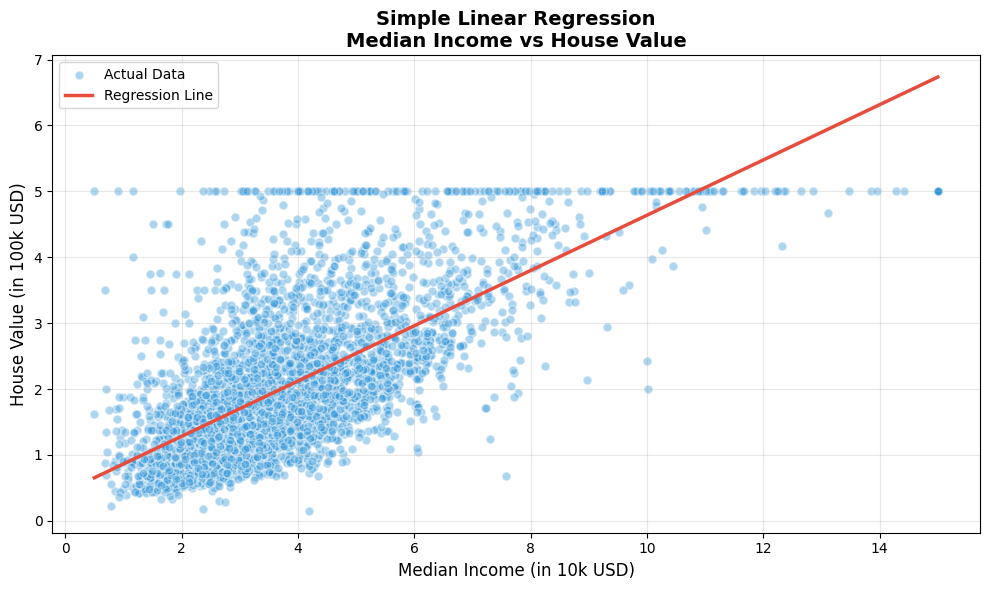

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')
cal_housing = fetch_california_housing()
df = pd.DataFrame(cal_housing.data, columns=cal_housing.feature_names)
df['MedHouseVal'] = cal_housing.target
X = df[['MedInc']]
y = df['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
plt.figure(figsize=(10, 6))
plt.scatter(X_test['MedInc'], y_test, alpha=0.4, color='#3498db', 
            edgecolors='white', s=40, label='Actual Data')
X_vals = np.linspace(X_test['MedInc'].min(), X_test['MedInc'].max(), 100).reshape(-1, 1)
y_vals = model.predict(X_vals)
plt.plot(X_vals, y_vals, color='#e74c3c', linewidth=2.5, label='Regression Line')
plt.title('Simple Linear Regression\nMedian Income vs House Value', fontsize=14, fontweight='bold')
plt.xlabel('Median Income (in 10k USD)', fontsize=12)
plt.ylabel('House Value (in 100k USD)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('graph_01_simple_lr.png', dpi=300, bbox_inches='tight')
plt.show()

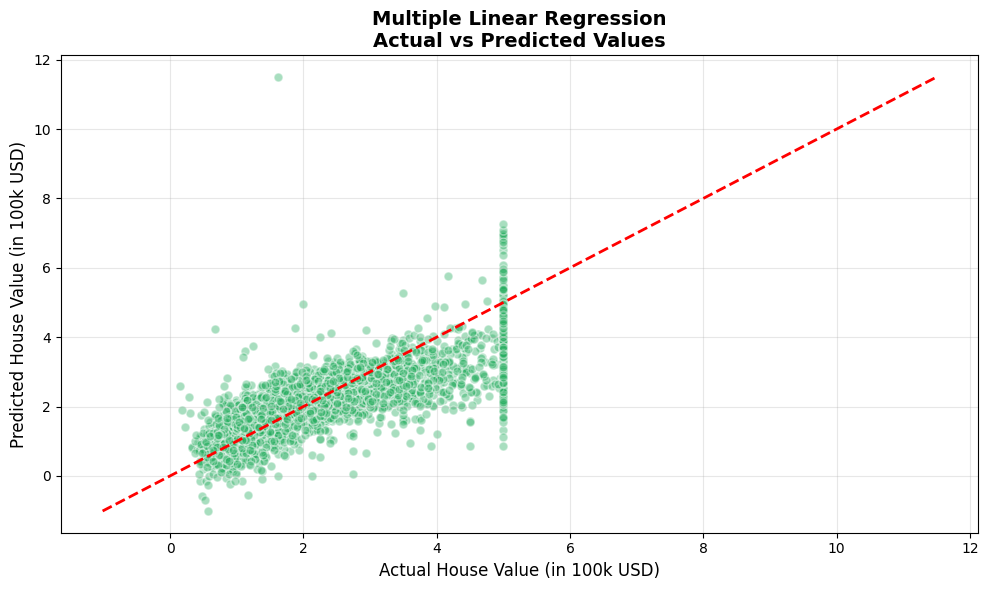

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')
cal_housing = fetch_california_housing()
df = pd.DataFrame(cal_housing.data, columns=cal_housing.feature_names)
df['MedHouseVal'] = cal_housing.target
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='#27ae60', edgecolors='white', s=40)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
plt.title('Multiple Linear Regression\nActual vs Predicted Values', fontsize=14, fontweight='bold')
plt.xlabel('Actual House Value (in 100k USD)', fontsize=12)
plt.ylabel('Predicted House Value (in 100k USD)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('graph_02_actual_pred.png', dpi=300, bbox_inches='tight')
plt.show()

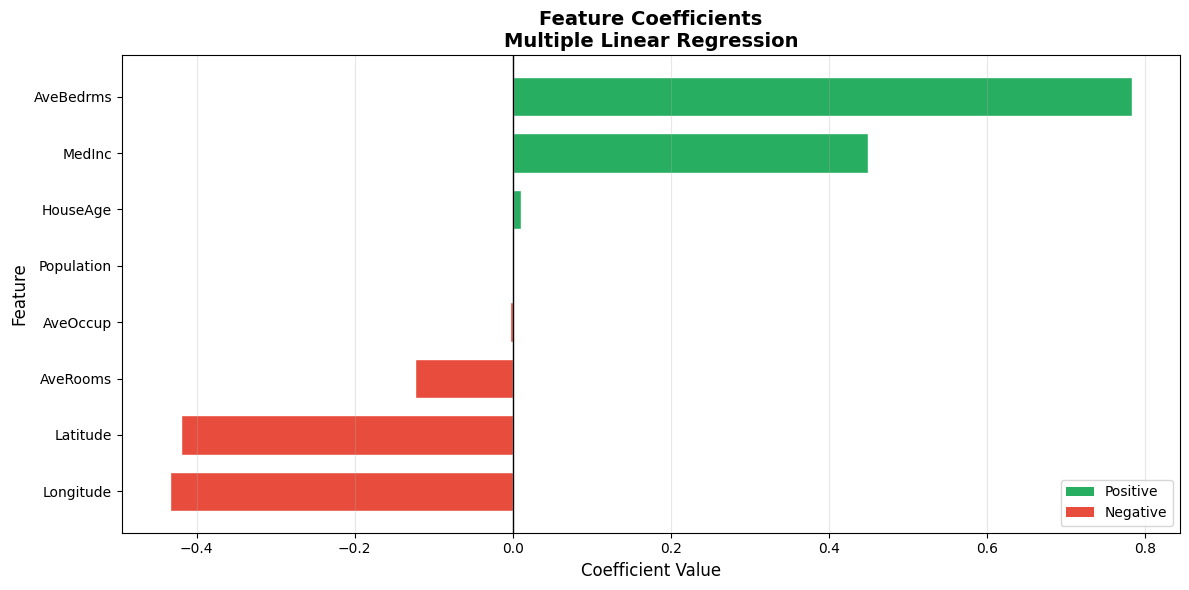

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')
cal_housing = fetch_california_housing()
df = pd.DataFrame(cal_housing.data, columns=cal_housing.feature_names)
df['MedHouseVal'] = cal_housing.target
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
coef_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
coef_df = coef_df.sort_values(by='Coefficient', ascending=True)
plt.figure(figsize=(12, 6))
colors = ['#e74c3c' if x < 0 else '#27ae60' for x in coef_df['Coefficient']]
plt.barh(coef_df.index, coef_df['Coefficient'], color=colors, edgecolor='white', height=0.7)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)

plt.title('Feature Coefficients\nMultiple Linear Regression', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(True, alpha=0.3, axis='x')
plt.legend(handles=[Patch(facecolor='#27ae60', label='Positive'),
              Patch(facecolor='#e74c3c', label='Negative')], loc='lower right')
plt.tight_layout()
plt.savefig('graph_03_coefficients.png', dpi=300, bbox_inches='tight')
plt.show()

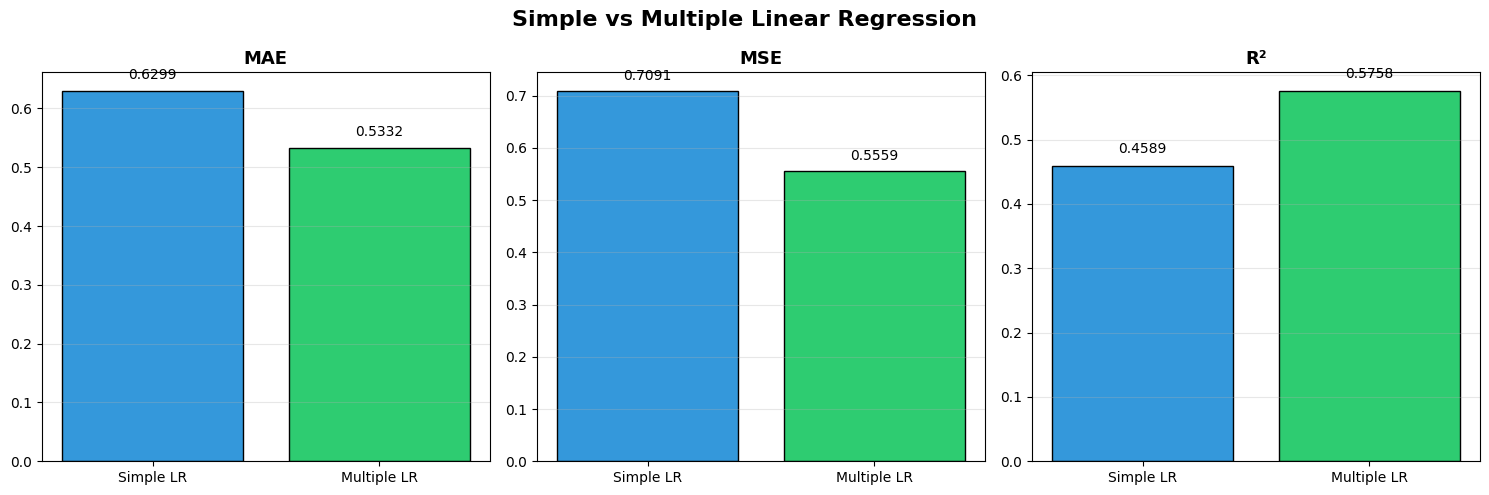

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
cal_housing = fetch_california_housing()
df = pd.DataFrame(cal_housing.data, columns=cal_housing.feature_names)
df['MedHouseVal'] = cal_housing.target
X_s = df[['MedInc']]
y = df['MedHouseVal']
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_s, y, test_size=0.2, random_state=42)
X_m = df.drop('MedHouseVal', axis=1)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_m, y, test_size=0.2, random_state=42)
pred_s = LinearRegression().fit(X_train_s, y_train_s).predict(X_test_s)
pred_m = LinearRegression().fit(X_train_m, y_train_m).predict(X_test_m)
metrics = {
    'MAE': [mean_absolute_error(y_test_s, pred_s), mean_absolute_error(y_test_m, pred_m)],
    'MSE': [mean_squared_error(y_test_s, pred_s), mean_squared_error(y_test_m, pred_m)],
    'R²': [r2_score(y_test_s, pred_s), r2_score(y_test_m, pred_m)]
}
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#3498db', '#2ecc71']
for i, (ax, metric) in enumerate(zip(axes, ['MAE', 'MSE', 'R²'])):
    bars = ax.bar(['Simple LR', 'Multiple LR'], metrics[metric], color=colors, edgecolor='black')
    ax.set_title(f'{metric}', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, metrics[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.4f}', ha='center', fontsize=10)
plt.suptitle('Simple vs Multiple Linear Regression', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('graph_04_comparison.png', dpi=300, bbox_inches='tight')
plt.show()